# Widzenie komputerowe – Laboratorium 6  
## CNN Fundamentals
---

| | |
|---|---|
| **Prowadzący:** | Piotr Wyrwiński |
| **Kontakt:** | piotr.wyrwinski@cs.put.poznan.pl |

---

## Opis laboratorium

To laboratorium domyka przejście od klasycznego CV do głębokiego uczenia.  
Punkty odniesienia z poprzednich zajęć:
- filtrowanie i splot,
- detekcja krawędzi,
- reprezentacje częstotliwościowe,
- klasyczne cechy lokalne.

W tym notebooku:
1. porównasz filtry klasyczne z filtrami wyuczonymi przez CNN,
2. zbudujesz małą sieć CNN z podstawowych komponentów,
3. uzupełnisz pętlę uczenia,
4. zrobisz ablację architektury.


## Plan pracy

- **Część 0**: setup, CIFAR-10, wizualizacja danych  
- **Część 1**: filtry klasyczne vs filtry uczone  
- **Część 2**: architektura CNN z komponentów  
- **Część 3**: pętla uczenia  
- **Część 4**: ablacja architektury

Wszystkie dłuższe ćwiczenia mają oznaczenia:
- `# TODO`
- `# YOUR CODE HERE`


In [2]:

import random
import time
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision import datasets, models

## Część 0: Setup i dane

Korzystamy z CIFAR-10: 10 klas, obrazy RGB 32×32.


In [3]:

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Fast runtime switch:
# - True: smaller training subset for fast labs / CPU fallback
# - False: larger subset (still not full CIFAR-10 by default)
FAST_MODE = True

# Determinism note:
# full determinism can slow down training; we keep a pragmatic setting here
torch.backends.cudnn.benchmark = torch.cuda.is_available()

Device: cpu


In [4]:

# Transforms
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)

train_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(cifar_mean, cifar_std),
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(cifar_mean, cifar_std),
])

trainset_full = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
testset_full = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

class_names = trainset_full.classes
print(class_names)
print("Train size:", len(trainset_full))
print("Test size:", len(testset_full))

100%|██████████| 170M/170M [00:01<00:00, 92.1MB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000
Test size: 10000


In [5]:

# Fast subsets for training during lab
if FAST_MODE:
    train_indices = list(range(8000))
    test_indices = list(range(2000))
else:
    train_indices = list(range(20000))
    test_indices = list(range(5000))

trainset = Subset(trainset_full, train_indices)
testset = Subset(testset_full, test_indices)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

print("Train subset:", len(trainset))
print("Test subset:", len(testset))

Train subset: 8000
Test subset: 2000


In [6]:

# Helper functions
def denormalize(img_tensor, mean=cifar_mean, std=cifar_std):
    mean = torch.tensor(mean, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(std, device=img_tensor.device).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

def show_batch(images, labels, class_names, n=16):
    images = images[:n]
    labels = labels[:n]
    rows = int(np.sqrt(n))
    cols = int(np.ceil(n / rows))
    fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.2 * rows))
    axes = np.array(axes).reshape(rows, cols)
    for ax in axes.ravel():
        ax.axis("off")
    for i, ax in enumerate(axes.ravel()[:n]):
        img = denormalize(images[i].cpu()).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(class_names[int(labels[i])], fontsize=9)
    plt.tight_layout()
    plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * images.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += images.size(0)
    return total_loss / total_examples, total_correct / total_examples

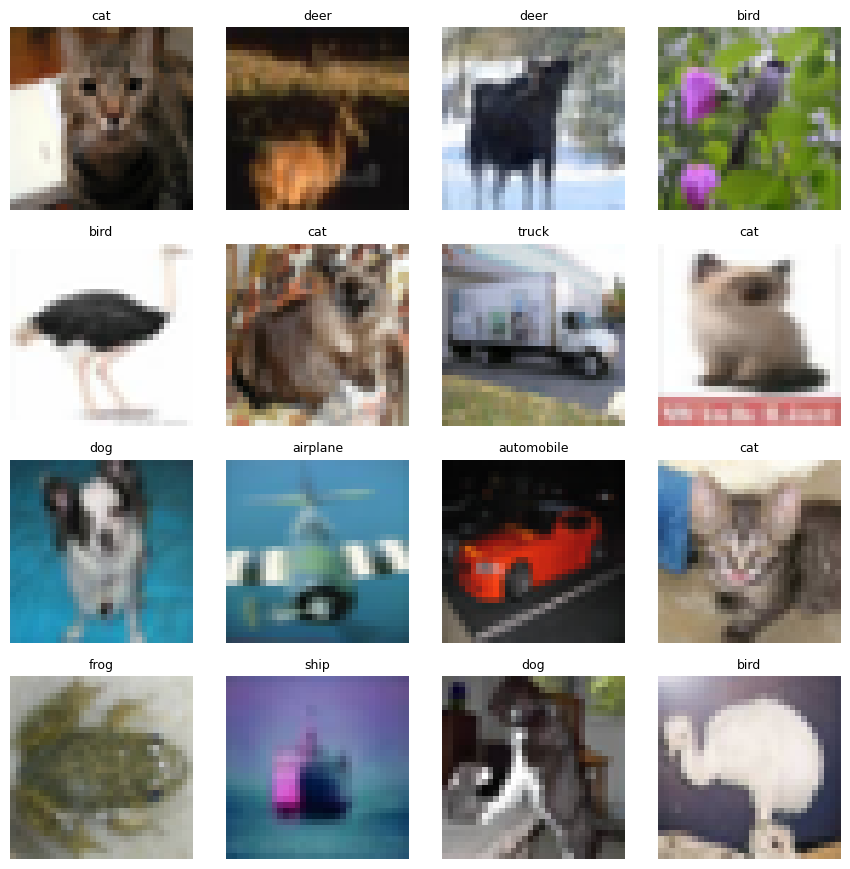

In [7]:

images, labels = next(iter(train_loader))
show_batch(images, labels, class_names, n=16)

### Pytanie kontrolne

Dlaczego dla CNN pracujących na obrazach kolorowych wejście ma kształt `B × 3 × H × W`, a nie `B × H × W × 3`?  
Odpowiedz jednym zdaniem.

Dla Bx3xHxW kanały kolorów mają jeden ciągły blok pamięci, co pozwala na szybszy odczyt sekwencyjny, w przeciwieństwie do BxHxWx3, gdzie wartości każdego kanału są przeplatane co 3 adresy, co wymusza nieciągły dostęp do pamięci.

## Część 1: Od filtrów klasycznych do filtrów uczonych

Warstwy CNN nadal wykonują **splot**. Różnica polega na tym, że kernele nie są projektowane ręcznie, tylko **uczone z danych**.

W tej części:
1. wyświetlisz kernele z pierwszej warstwy modelu VGG-16,
2. napiszesz funkcję `apply_kernel(image, kernel)`,
3. porównasz odpowiedzi filtrów klasycznych i wyuczonych na tym samym obrazie.



In [8]:
# Load pretrained VGG-16 from torchvision
weights = models.VGG16_Weights.DEFAULT
pretrained_model = models.vgg16(weights=weights).to(device).eval()

first_conv = pretrained_model.features[0]
kernel_tensor = first_conv.weight.detach().cpu()   # [64, 3, 3, 3]
print("First conv shape:", tuple(kernel_tensor.shape))


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 64.9MB/s]


First conv shape: (64, 3, 3, 3)


### Zadanie 1 – wizualizacja kerneli

Uzupełnij 3 linie tak, aby:
- wziąć **pierwsze 16 kerneli**,
- przekształcić je do postaci nadającej się do siatki obrazów,
- zbudować siatkę przez `torchvision.utils.make_grid`.

**Wskazówka:**  
`kernel_tensor[:16]` ma kształt `(16, 3, 3, 3)`.  
Po sprowadzeniu do skali szarości i dodaniu wymiaru kanału chcesz otrzymać tensor o kształcie **`(16, 1, 3, 3)`**.



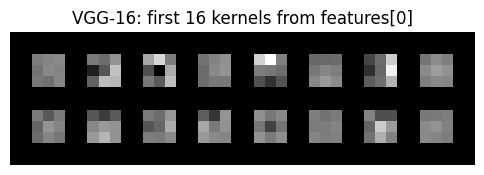

In [9]:
def normalize_for_display(x):
    x = x.clone()
    x = x - x.min()
    x = x / (x.max() - x.min() + 1e-8)
    return x

# TODO: complete the 3 lines below
kernels16 = kernel_tensor[:16]
kernels16 = TF.rgb_to_grayscale(kernels16)
kernels16 = normalize_for_display(kernels16)
kernel_grid = torchvision.utils.make_grid(kernels16)
assert kernels16.shape == (16, 1, 3, 3), f"Expected (16, 1, 3, 3), got {tuple(kernels16.shape)}"

plt.figure(figsize=(6, 6))
plt.imshow(kernel_grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("VGG-16: first 16 kernels from features[0]")
plt.axis("off")
plt.show()


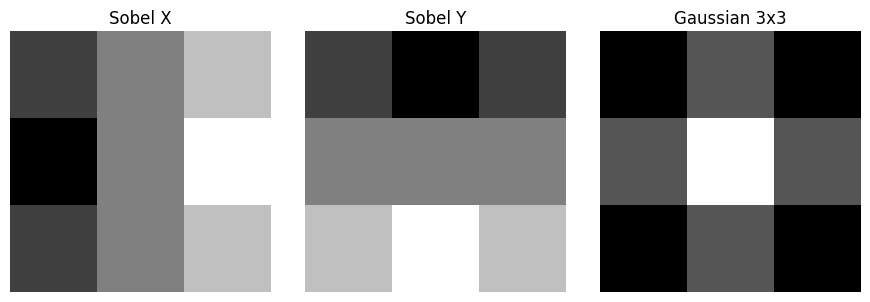

In [10]:
# Classical filters from previous labs
sobel_x = torch.tensor([
    [-1., 0., 1.],
    [-2., 0., 2.],
    [-1., 0., 1.]
])

sobel_y = torch.tensor([
    [-1., -2., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  2.,  1.]
])

gaussian_3x3 = torch.tensor([
    [1., 2., 1.],
    [2., 4., 2.],
    [1., 2., 1.]
]) / 16.0

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, k, title in zip(
    axes,
    [sobel_x, sobel_y, gaussian_3x3],
    ["Sobel X", "Sobel Y", "Gaussian 3x3"]
):
    ax.imshow(k.numpy(), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


### Zadanie 2 – napisz funkcję `apply_kernel`

Napisz funkcję:

```python
apply_kernel(image, kernel)
```

Specyfikacja:
- `image` ma wejść jako tensor 2D `(H, W)` albo 4D `(1, 1, H, W)`,
- `kernel` ma wejść jako tensor 2D `(k, k)` albo 4D `(1, 1, k, k)`,
- wewnątrz użyj `F.conv2d`,
- dodaj odpowiednie `unsqueeze`, jeśli trzeba,
- użyj `padding = kernel_size // 2`, żeby zachować rozmiar obrazu.

Na końcu przetestujesz tę funkcję na 3 wyuczonych kernelach: `#0`, `#3`, `#7`.



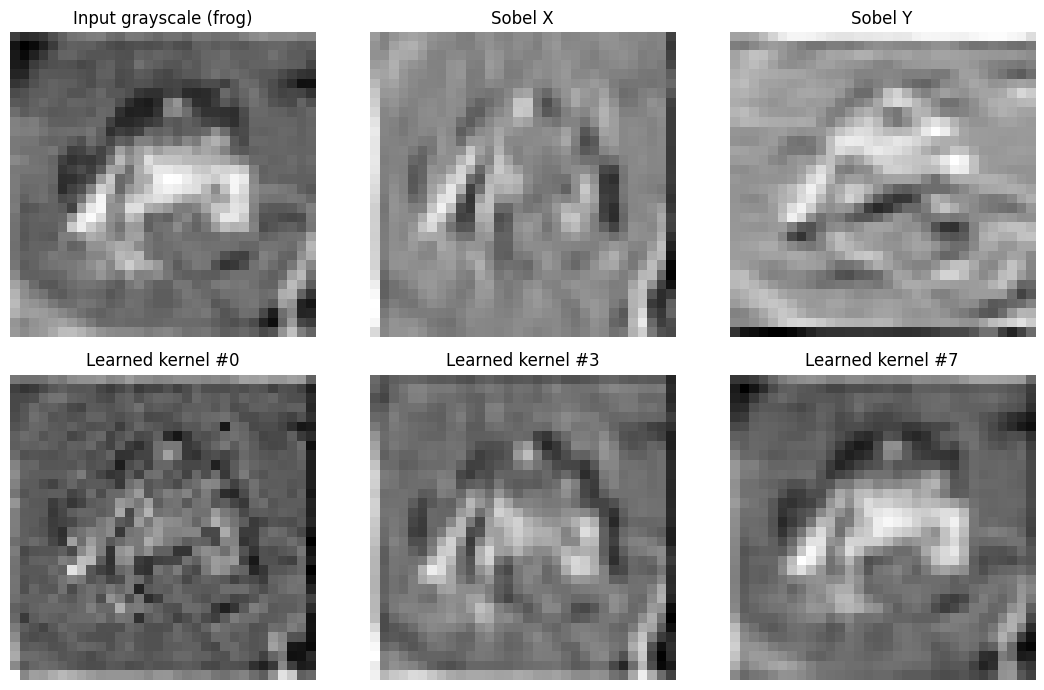

In [11]:
# Pick one example image and convert it to grayscale
sample_img, sample_label = trainset_full[0]
sample_img_denorm = denormalize(sample_img).cpu()
sample_gray_2d = (
    0.299 * sample_img_denorm[0] +
    0.587 * sample_img_denorm[1] +
    0.114 * sample_img_denorm[2]
)

def rgb_kernel_to_gray(kernel_rgb):
    # kernel_rgb: [3, k, k] -> [k, k]
    return kernel_rgb.mean(dim=0)

# TODO: complete the function below
def apply_kernel(image, kernel):
    # image: (H, W) or (1, 1, H, W)
    # kernel: (k, k) or (1, 1, k, k)

    if image.dim() == 2:
      image = image.unsqueeze(0).unsqueeze(0) # H,W -> 1,1,H,W
    if kernel.dim() == 2:
      kernel = kernel.unsqueeze(0).unsqueeze(0) # k,k -> 1,1,k,k

    k = kernel.shape[-1]
    pad = k // 2

    return F.conv2d(image, kernel, padding=pad)

# Basic tests
test_out = apply_kernel(sample_gray_2d, sobel_x)
assert test_out.shape == (1, 1, 32, 32), f"Expected (1,1,32,32), got {tuple(test_out.shape)}"

learned_k0 = rgb_kernel_to_gray(kernel_tensor[0])
learned_k3 = rgb_kernel_to_gray(kernel_tensor[3])
learned_k7 = rgb_kernel_to_gray(kernel_tensor[7])

out_sobel_x = apply_kernel(sample_gray_2d, sobel_x)
out_sobel_y = apply_kernel(sample_gray_2d, sobel_y)
out_k0 = apply_kernel(sample_gray_2d, learned_k0)
out_k3 = apply_kernel(sample_gray_2d, learned_k3)
out_k7 = apply_kernel(sample_gray_2d, learned_k7)

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes[0, 0].imshow(sample_gray_2d.numpy(), cmap="gray")
axes[0, 0].set_title(f"Input grayscale ({class_names[sample_label]})")
axes[0, 1].imshow(out_sobel_x[0, 0].detach().numpy(), cmap="gray")
axes[0, 1].set_title("Sobel X")
axes[0, 2].imshow(out_sobel_y[0, 0].detach().numpy(), cmap="gray")
axes[0, 2].set_title("Sobel Y")
axes[1, 0].imshow(out_k0[0, 0].detach().numpy(), cmap="gray")
axes[1, 0].set_title("Learned kernel #0")
axes[1, 1].imshow(out_k3[0, 0].detach().numpy(), cmap="gray")
axes[1, 1].set_title("Learned kernel #3")
axes[1, 2].imshow(out_k7[0, 0].detach().numpy(), cmap="gray")
axes[1, 2].set_title("Learned kernel #7")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()


### Krótka analiza

Porównaj filtry wyuczone z Sobelem i Gaussowskim wygładzaniem.

Napisz **3–4 zdania**:
1. które wyuczone kernele przypominają detektory krawędzi,
2. czy widzisz orientację, asymetrię albo selektywność na kontrast,
3. jakie wzorce pojawiają się w filtrach uczonych, których nie oddają proste filtry klasyczne.

Kernele #3 i #7 jako detektory krawędzi. Kernel #3 daje odpowiedź bardzo zbliżoną do Sobela Y — widać wyraźne poziome krawędzie, szczególnie zarys żaby od góry i dołu. Kernel #7 z kolei zachowuje się podobnie do Sobela X, podkreślając pionowe przejścia jasność-ciemność po bokach sylwetki. orównując #3 i #7, widać wyraźną asymetrię odpowiedzi - jeden preferuje poziome, drugi pionowe przejścia kontrastu. Odpowiedź kernela #0 wygląda jak szum: drobna, ziarnista tekstura bez wyraźnej struktury przestrzennej.



## Część 2: CNN z komponentów

Teraz przejdziesz od pojedynczych filtrów do całej architektury CNN.

Wzorzec bazowego bloku:
`Conv2d → BatchNorm2d → ReLU → MaxPool2d`

Najpierw uzupełnisz brakujące elementy. Potem samodzielnie rozszerzysz model o drugi blok konwolucyjny.



### Zadanie 3 – uzupełnij architekturę z lukami

W tej komórce znajdują się **4 miejsca do poprawy**:
1. nieprawidłowy `in_channels` w drugim bloku,
2. brak aktywacji po `BatchNorm2d`,
3. brak poolingu,
4. nieprawidłowa liczba `in_features` w pierwszej warstwie liniowej.

Po każdej poprawce uruchom testy shape'ów poniżej. Od razu zobaczysz, czy model działa poprawnie.

In [12]:
class StudentCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # (B, 3, 32, 32) -> (B, 32, 32, 32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2), # (B, 32, 32, 32) -> (B, 32, 16, 16)
        )

        self.block2 = nn.Sequential(
            # TODO 1: fix in_channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (B, 32, 16, 16) -> (B, 64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2) # (B, 64, 16, 16) -> (B, 64, 8, 8)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(), # cifar-10: 32x32, po maxpool2d do 16x16, później znowu, więc 8x8
            # out_channel z block2: 64, czyli 64*8*8 = 4096
            # TODO 4: fix in_features after flatten
            nn.Linear(4096, 128), # (B,64,8,8) -> (B,4096)
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

student_model = StudentCNN().to(device)
print(student_model)


StudentCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [13]:
# Shape assertions
try:
    dummy = torch.randn(2, 3, 32, 32).to(device)

    x1 = student_model.block1(dummy)
    assert x1.shape == (2, 32, 16, 16), f"block1 should output (2,32,16,16), got {tuple(x1.shape)}"

    x2 = student_model.block2(x1)
    assert x2.shape == (2, 64, 8, 8), f"block2 should output (2,64,8,8), got {tuple(x2.shape)}"

    out = student_model(dummy)
    assert out.shape == (2, 10), f"Model output should be (2,10), got {tuple(out.shape)}"

    print("All shape tests passed.")
except Exception as e:
    print("Shape test failed:")
    print(e)


All shape tests passed.


### Zadanie 4 – zamień klasyczny head na Global Average Pooling

Do tej pory używaliśmy klasyfikatora w stylu:
`Flatten -> Linear -> ReLU -> Linear`.

Teraz zrobisz popularną alternatywę:
- zostaw część konwolucyjną bez zmian,
- dodaj `AdaptiveAvgPool2d((1, 1))`,
- usuń duży `Flatten` po mapie cech `32 x 16 x 16`,
- zbuduj prostszy head, który działa na wektorze długości `32`.

To jest często używane w CNN-ach, bo mocno zmniejsza liczbę parametrów.

In [14]:


class GAPCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16
        )

        # TODO: add global average pooling
        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            # TODO: flatten pooled tensor
            nn.Flatten(),
            # TODO: linear layer from 32 features to num_classes
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        assert x.shape[1:] == (32, 16, 16), f"After features expected (32,16,16), got {tuple(x.shape[1:])}"

        # TODO: apply global average pooling
        x = self.gap(x)
        assert x.shape[1:] == (32, 1, 1), f"After GAP expected (32,1,1), got {tuple(x.shape[1:])}"

        x = self.classifier(x)
        return x

gap_model = GAPCNN().to(device)

try:
    out = gap_model(torch.randn(1, 3, 32, 32).to(device))
    assert out.shape == (1, 10), f"Expected (1,10), got {tuple(out.shape)}"
    print("Model is valid.")
except Exception as e:
    print("Complete the missing parts, then rerun this cell.")
    print(e)

Model is valid.


### Sprawdź liczbę parametrów i skomentuj wynik

Uruchom utility niżej dla:
- swojej poprawionej wersji `StudentCNN`,
- modelu `GAPCNN` z poprzedniego zadania.

Porównaj wyniki i napisz krótko:
1. w którym modelu jest więcej parametrów:

StudentCNN

2. która warstwa najbardziej zwiększa liczbę parametrów w `StudentCNN`:

classifier.1.weight shape=(128, 4096) params=524288

3. dlaczego zastąpienie `Flatten` + dużej warstwy `Linear` przez `Global Average Pooling` zmniejsza liczbę parametrów:

GAP uśrednia każdy kanał do jednej liczby — tensor (B, 32, 16, 16) staje się (B, 32, 1, 1), a po Flatten wektorem długości 32. Warstwa liniowa Linear(32, 10) ma więc tylko 320 parametrów zamiast ponad pół miliona

4. co taki prostszy head może zyskać, a co może stracić.

Zyskuje przede wszystkim lepszą generalizację na małych datasetach mniej parametrów to mniejsza szansa na overfit. Traci natomiast informację o położeniu cech w obrazie.

In [15]:
def parameter_table(model):
    rows = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            rows.append((name, tuple(param.shape), param.numel()))
    return rows

for model_name, model_obj in [
    ("StudentCNN", student_model),
    ("GAPCNN", gap_model),
]:
    print(f"\n=== {model_name} ===")
    total = 0
    for name, shape, num in parameter_table(model_obj):
        total += num
        print(f"{name:35s} shape={str(shape):18s} params={num}")
    print("TOTAL:", total)


=== StudentCNN ===
block1.0.weight                     shape=(32, 3, 3, 3)      params=864
block1.0.bias                       shape=(32,)              params=32
block1.1.weight                     shape=(32,)              params=32
block1.1.bias                       shape=(32,)              params=32
block2.0.weight                     shape=(64, 32, 3, 3)     params=18432
block2.0.bias                       shape=(64,)              params=64
block2.1.weight                     shape=(64,)              params=64
block2.1.bias                       shape=(64,)              params=64
classifier.1.weight                 shape=(128, 4096)        params=524288
classifier.1.bias                   shape=(128,)             params=128
classifier.3.weight                 shape=(10, 128)          params=1280
classifier.3.bias                   shape=(10,)              params=10
TOTAL: 545290

=== GAPCNN ===
features.0.weight                   shape=(32, 3, 3, 3)      params=864
features.0.bias

## Część 3: Pętla uczenia

Czas złożyć najważniejszy element tego laboratorium:
**własną pętlę treningową**.

Przejdziesz przez 4 krótkie kroki, weryfikując po każdym poprawność działania, a na koniec zamkniesz całość w funkcji, którą wykorzystasz w dalszej części ćwiczenia.

In [16]:
exercise_model = StudentCNN().to(device)
exercise_loss_fn = nn.CrossEntropyLoss()
exercise_optimizer = torch.optim.Adam(exercise_model.parameters(), lr=1e-3)

batch_images, batch_labels = next(iter(train_loader))
batch_images = batch_images.to(device)
batch_labels = batch_labels.to(device)
print("Batch shape:", tuple(batch_images.shape), tuple(batch_labels.shape))


Batch shape: (128, 3, 32, 32) (128,)


### Zadanie 5 - 4 mini-kroki z walidacją

Uzupełniaj po kolei.

1. Policz `logits` i `loss`.  
2. Zrób backpropagation.  
3. Wykonaj `optimizer.step()` i `optimizer.zero_grad()`.  
4. Zrób poprawny evaluation pass z `model.eval()` i `torch.no_grad()`.



In [17]:
# Mini-exercise: one training step + one evaluation step

# Save one parameter tensor to verify that optimizer.step() changed it
weight_before = exercise_model.block1[0].weight.detach().clone()

# TODO 1: compute predictions and loss
logits = exercise_model(batch_images)
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, batch_labels)


assert loss.ndim == 0, f"Loss should be a scalar tensor, got shape {tuple(loss.shape)}"

# TODO 2: backpropagation
loss.backward()

assert exercise_model.block1[0].weight.grad is not None, "Gradient should not be None after backward()"

# TODO 3: optimizer step + zero grad
optimizer = torch.optim.SGD(exercise_model.parameters(), lr=0.01, momentum=0.9)
optimizer.step()
optimizer.zero_grad()
weight_after = exercise_model.block1[0].weight.detach().clone()
assert not torch.allclose(weight_before, weight_after), "Parameters should change after optimizer.step()"

# TODO 4: evaluation pass with model.eval() and torch.no_grad()
# Hints:
# - switch to eval mode
# - compute eval_logits without tracking gradients
# - compute eval_preds with argmax
# - switch back to train mode if needed
exercise_model.eval()
with torch.no_grad():
    eval_logits = exercise_model(batch_images)
    eval_preds = torch.argmax(eval_logits, dim=1)

exercise_model.train()

assert eval_logits.shape[0] == batch_images.shape[0], "Batch size should stay the same during evaluation"
assert eval_preds.shape == batch_labels.shape, "Predictions should have shape (batch_size,)"
print("Mini-step finished correctly.")


Mini-step finished correctly.


### Zadanie 6 - zapakuj to do funkcji `train_and_log`

Teraz przenieś logikę z poprzedniego zadania do funkcji wieloepokowej.

Specyfikacja:
- wejście: `model, train_loader, test_loader, optimizer, loss_fn, epochs`,
- wyjście:
```python
{
    "train_loss": [...],
    "test_acc": [...],
}
```
- w każdej epoce:
  - trening z `model.train()`,
  - ewaluacja z `model.eval()` oraz `torch.no_grad()`.

Ta funkcja będzie potrzebna też w kolejnych częściach notebooka.



In [18]:
def train_and_log(model, train_loader, test_loader, optimizer, loss_fn, epochs=5):
    history = {"train_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total_examples = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            # TODO: training step
            # 1) forward
            # 2) loss
            # 3) zero_grad
            # 4) backward
            # 5) optimizer.step()
            # YOUR CODE HERE

            running_loss += loss.item() * images.size(0)
            total_examples += images.size(0)

        train_loss = running_loss / total_examples

        # TODO: evaluation step
        # Use model.eval() and torch.no_grad()
        model.eval()
        total_correct = 0
        total_test = 0
        with torch.no_grad():
          for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_test += images.size(0)

        test_acc = total_correct / total_test
        history["train_loss"].append(train_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | train loss={train_loss:.4f} | test acc={test_acc:.4f}")

    return history

# After implementing the function, uncomment the block below.
model = StudentCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 5 if FAST_MODE else 8
history = train_and_log(model, train_loader, test_loader, optimizer, loss_fn, epochs=EPOCHS)


Epoch 01/5 | train loss=1.7257 | test acc=0.4460
Epoch 02/5 | train loss=1.3016 | test acc=0.5325
Epoch 03/5 | train loss=1.1438 | test acc=0.5695
Epoch 04/5 | train loss=0.9716 | test acc=0.5980
Epoch 05/5 | train loss=0.8482 | test acc=0.6060


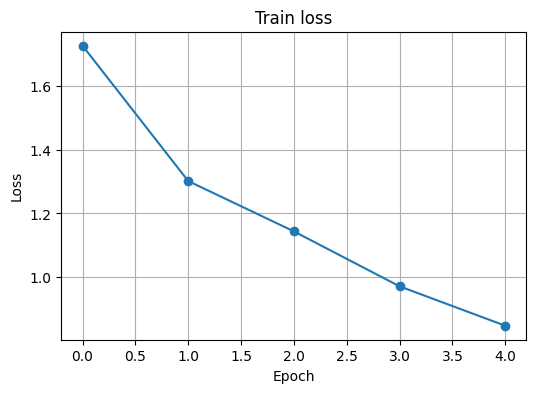

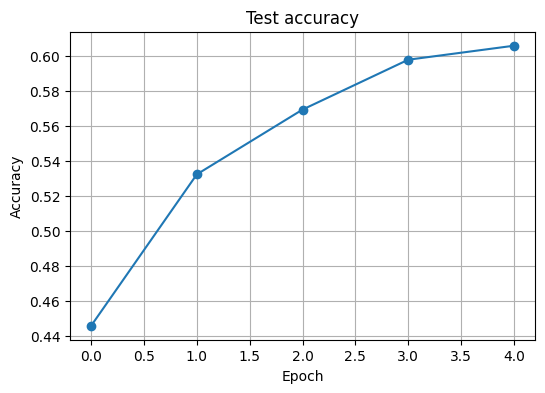

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], marker="o")
plt.title("Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history["test_acc"], marker="o")
plt.title("Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


### Orientacyjne wyniki referencyjne

Przy `FAST_MODE=True` i 5 epokach typowy zakres to:
- `train_loss`: mniej więcej od **1.8–2.0** w dół do **0.8–1.2**,
- `test_acc`: mniej więcej **0.55–0.70** po 5 epokach.


### Zadanie 7

Uruchom 4 eksperymenty diagnostyczne.  
Każdy wariant ma używać **Twojej** funkcji `train_and_log` albo jej bezpośredniego rozszerzenia.

Eksperymenty:
1. `lr = 10.0`,
2. brak `optimizer.zero_grad()`,
3. `MSELoss` zamiast `CrossEntropyLoss`,
4. brak przełączania `model.train()` / `model.eval()`.

Uzupełnij tabelę:

| Bug | Symptom (loss curve) | Accuracy after 2 epochs | Explanation |
|---|---|---|---|
| lr = 10.0 | eksplozja gradientów w 1. epoce | ok. 10% | zbyt duży krok niszczy wagi w pierwszej epoce |
| no zero_grad | bez poprawy od 3. epoki | ok. 9,5% | akumulacja gradientów powoduje chaotyczne aktualizacje |
| MSELoss | płynny spadek loss i niemonotoniczny wzrost accuracy | ok. 19% | MSE nie optymalizuje bezpośrednio pod kątem klasyfikacji |
| no train/eval switching | zwyczajny trening | ok. 60% | działa dobrze na małej skali, ale dla większych instancji mogą pojawić się problemy - mały dataset, jedna konwolucja, stałe statystyki treningowe i testowe |



In [20]:
# Optional helper for the diagnostic experiments.
# You can either:
# 1) modify a copy of your train_and_log function, or
# 2) write a thin wrapper with switches like below.

def train_and_log_debug(
    model,
    train_loader,
    test_loader,
    optimizer,
    loss_fn,
    epochs=2,
    use_zero_grad=True,
    use_mode_switch=True,
    use_one_hot_for_mse=False,
):
    history = {"train_loss": [], "test_acc": []}

    for epoch in range(epochs):
        if use_mode_switch:
            model.train()

        running_loss = 0.0
        total_examples = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # TODO: adapt your training code here
            # Hint for MSE: you may need one-hot targets
            if use_zero_grad:
              optimizer.zero_grad()

            logits = model(images)

            if use_one_hot_for_mse:
              targets = torch.zeros_like(logits)
              targets.scatter_(1, labels.unsqueeze(1), 1)
              loss = loss_fn(logits, targets)
            else:
              loss = loss_fn(logits, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total_examples += images.size(0)

        train_loss = running_loss / total_examples

        if use_mode_switch:
            model.eval()

        total_correct = 0
        total_test = 0
        # TODO: adapt your evaluation code here
        with torch.no_grad():
          for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_test += labels.size(0)

        test_acc = total_correct / total_test
        history["train_loss"].append(train_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | train loss={train_loss:.4f} | test acc={test_acc:.4f}")

    return history


Uruchamiaj poniższe warianty **po jednym naraz** i notuj objawy.



In [21]:
# Experiment A: absurdly high learning rate
# TODO: run this experiment with your working model and training function

debug_model = StudentCNN().to(device)
debug_optimizer = torch.optim.Adam(debug_model.parameters(), lr=10.0)
debug_loss_fn = nn.CrossEntropyLoss()
hist_high_lr = train_and_log_debug(
     debug_model, train_loader, test_loader, debug_optimizer, debug_loss_fn, epochs=5
)


Epoch 01/5 | train loss=1524992.2439 | test acc=0.0925
Epoch 02/5 | train loss=41.8965 | test acc=0.1085
Epoch 03/5 | train loss=2.5352 | test acc=0.0990
Epoch 04/5 | train loss=2.4450 | test acc=0.0925
Epoch 05/5 | train loss=2.4828 | test acc=0.0990


In [22]:
# Experiment B: missing zero_grad
# TODO: run this experiment after adapting train_and_log_debug

debug_model = StudentCNN().to(device)
debug_optimizer = torch.optim.Adam(debug_model.parameters(), lr=1e-3)
debug_loss_fn = nn.CrossEntropyLoss()
hist_no_zero_grad = train_and_log_debug(
     debug_model, train_loader, test_loader, debug_optimizer, debug_loss_fn,
     epochs=5, use_zero_grad=False
 )


Epoch 01/5 | train loss=2.7375 | test acc=0.1720
Epoch 02/5 | train loss=2.2474 | test acc=0.1610
Epoch 03/5 | train loss=2.2738 | test acc=0.1000
Epoch 04/5 | train loss=2.3060 | test acc=0.1045
Epoch 05/5 | train loss=2.3044 | test acc=0.1280


In [23]:
# Experiment C: wrong loss for classification
# TODO: run this experiment after adapting train_and_log_debug

debug_model = StudentCNN().to(device)
debug_optimizer = torch.optim.Adam(debug_model.parameters(), lr=1e-3)
debug_loss_fn = nn.MSELoss()
hist_mse = train_and_log_debug(
     debug_model, train_loader, test_loader, debug_optimizer, debug_loss_fn,
     epochs=5, use_one_hot_for_mse=True
)


Epoch 01/5 | train loss=0.1876 | test acc=0.1365
Epoch 02/5 | train loss=0.0859 | test acc=0.2625
Epoch 03/5 | train loss=0.0833 | test acc=0.2915
Epoch 04/5 | train loss=0.0816 | test acc=0.2825
Epoch 05/5 | train loss=0.0805 | test acc=0.2965


In [24]:
# Experiment D: missing train/eval switching
# TODO: run this experiment after adapting train_and_log_debug

debug_model = StudentCNN().to(device)
debug_optimizer = torch.optim.Adam(debug_model.parameters(), lr=1e-3)
debug_loss_fn = nn.CrossEntropyLoss()
hist_no_mode_switch = train_and_log_debug(
     debug_model, train_loader, test_loader, debug_optimizer, debug_loss_fn,
     epochs=5, use_mode_switch=False
)


Epoch 01/5 | train loss=1.7518 | test acc=0.4785
Epoch 02/5 | train loss=1.3219 | test acc=0.5505
Epoch 03/5 | train loss=1.1239 | test acc=0.5795
Epoch 04/5 | train loss=0.9997 | test acc=0.5725
Epoch 05/5 | train loss=0.9008 | test acc=0.6055


## Część 4: Ablacja architektury

Teraz skorzystasz z gotowej funkcji `train_and_log`, aby porównać kilka wariantów architektonicznych.

Przed uruchomieniem treningu:
1. przeczytaj kod każdego wariantu,
2. wskaż, co dokładnie się zmieniło,
3. zapisz swoją **predykcję** wyniku.

Dopiero potem porównaj przewidywania z rzeczywistymi rezultatami.

In [28]:
@dataclass
class CNNConfig:
    channels: tuple = (32, 64)
    kernel_size: int = 3
    use_pool: bool = True
    extra_block: bool = False

class ConfigurableCNN(nn.Module):
    def __init__(self, config: CNNConfig, num_classes=10):
        super().__init__()
        c1, c2 = config.channels
        k = config.kernel_size
        p = k // 2

        layers = []
        in_ch = 3
        spatial = 32

        for out_ch in [c1, c2]:
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
            ]
            if config.use_pool:
                layers += [nn.MaxPool2d(2)]
                spatial //= 2
            in_ch = out_ch

        if config.extra_block:
            layers += [
                nn.Conv2d(in_ch, in_ch * 2, kernel_size=k, padding=p),
                nn.BatchNorm2d(in_ch * 2),
                nn.ReLU(),
            ]
            in_ch = in_ch * 2
            if config.use_pool and spatial >= 2:
                layers += [nn.MaxPool2d(2)]
                spatial //= 2

        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch * spatial * spatial, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

variant_configs = {
    "baseline": CNNConfig(channels=(32, 64), kernel_size=3, use_pool=True, extra_block=False),
    "double_filters": CNNConfig(channels=(64, 128), kernel_size=3, use_pool=True, extra_block=False),
    "kernel_5x5": CNNConfig(channels=(32, 64), kernel_size=5, use_pool=True, extra_block=False),
    "no_pooling": CNNConfig(channels=(32, 64), kernel_size=3, use_pool=False, extra_block=False),
    "deeper": CNNConfig(channels=(32, 64), kernel_size=3, use_pool=True, extra_block=True)
}

for name, cfg in variant_configs.items():
    model = ConfigurableCNN(cfg).to(device)
    print(f"{name:15s} params={count_parameters(model)}")


baseline        params=545290
double_filters  params=1126026
kernel_5x5      params=579594
no_pooling      params=8409610
deeper          params=357258
my_variant      params=8455562


### Zanim uruchomisz trening – zapisz przewidywania

Przed treningiem uzupełnij tabelę ręcznie:

| Variant | Co zmieniono? | Moja predykcja przed treningiem |
|---|---|---|
| baseline | 2 bloki conv (32->64), kernel 3x3, pooling | ok. 60% acc po 5 epokach |
| double_filters | dwa razy więcej kanałów (64->128), więcej parametrów w conv i linear | lepiej niż baseline, ale ryzyko overfittingu ze względu na mały dataset |
| kernel_5x5 | większy kernel, więcej wag w conv, bo kernel to tensor 3d (kanały * h * w)| podobnie do baseline |
| no_pooling | brak maxpool2d, stały spacial, bardzo duża warstwa linear | pomimo dużej liczby parametrów, gorsze acc niż baseline, ryzyko overfittingu |
| deeper | trzeci, dodatkowy blok konwolucji | na papierze najlepszy, ale być może potrzeba mu więcej niż 5 epok, aby się "rozkręcić" |

Najpierw spróbuj przewidzieć efekt, dopiero potem uruchom trening.



### Dodaj własny wariant

Zmień **co najmniej dwie rzeczy naraz**.  
Przykłady:
- większe filtry **i** więcej kanałów,
- brak poolingu **i** dodatkowy blok,
- więcej kanałów **i** głębsza sieć.

Nadaj swojemu wariantowi nazwę i zapisz wcześniej przewidywany efekt.



In [27]:
# TODO: create your own config with at least two simultaneous changes
my_variant_name = "test1"
my_variant_config = CNNConfig(
    channels=(16, 32),
    kernel_size=5,
    use_pool=False,
    extra_block=True,
)

my_variant_model = ConfigurableCNN(my_variant_config).to(device)
dummy_out = my_variant_model(torch.randn(1, 3, 32, 32).to(device))
assert dummy_out.shape == (1, 10), f"Expected (1,10), got {tuple(dummy_out.shape)}"
print(my_variant_name, "params=", count_parameters(my_variant_model))


test1 params= 8455562


### Uruchom wszystkie warianty i porównaj wyniki

Teraz sprawdź, czy przewidywania były trafne.

Uzupełnij tabelę:

| Variant | Params | Train Acc | Test Acc | Training Time |
|---|---:|---:|---:|---:|
| baseline | 545 290 | 69.70% | 57.75% | 98.1s |
| double_filters | 1 126 026 | 68.09% | 58.45% | 234.4s |
| kernel_5x5 | 579 594 | 69.90% | 56.95% | 119.0s |
| no_pooling | 8 409 610 | 73.76% | 51.90% | 285.5s |
| deeper | 357 258 | 77.31% | 64.10% | 117.2s |
| my_variant | 8 455 562 | 57.87% | 50.15% | 464.0s |

Na końcu napisz krótko:

1. **Która zmiana pomogła najbardziej** - `extra_block=True` (wariant *deeper*) dał najlepszy wynik: 64.1% test acc przy zaledwie 357k parametrów, co jest lepsze od baseline o ponad 6 punktów procentowych i jednocześnie przy mniejszej liczbie parametrów. Głębokość sieci okazała się ważniejsza niż szerokość czy rozmiar kerneli.

2. **Która zaszkodziła** - `use_pool=False`. Oba warianty bez poolingu (*no_pooling* i *my_variant*) wypadły najgorzej pod względem test acc (51.9% i 50.1%), mimo największej liczby parametrów (8.4M) i najdłuższego czasu treningu (285s i 464s). Co więcej, *no_pooling* ma wysokie train acc (73.8%) przy niskim test acc - oznaka overfittingu.

3. **Predykcja dla my_variant** była poprawna co do kierunku — wypadł słabiej niż baseline — ale nie przewidziałem jak bardzo wysoki będzie czas treningu (464s, prawie 5x wolniej niż baseline) ani że train acc będzie najniższe ze wszystkich wariantów (57.9%). Kombinacja małych kanałów (16, 32) z brakiem poolingu i extra_block okazała się wyjątkowo nieefektywna.

4. **Co zaskoczyło** - wariant *deeper* ma mniej parametrów niż baseline (357k vs 545k) i jest szybszy w treningu (117s vs 98s), a mimo to daje najlepszy wynik. Dodanie trzeciego bloku konwolucyjnego *zmniejszyło* model, bo głębszy pooling zredukował spatial z 8×8 do 4×4, co drastycznie zmniejszyło rozmiar warstwy liniowej. Jednocześnie *double_filters* z ponad 2x większą liczbą parametrów i 2.4x dłuższym treningiem dał praktycznie identyczny wynik co baseline (58.5% vs 57.8%).



In [29]:
def run_variant(config, epochs=5):
    model = ConfigurableCNN(config).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    start = time.time()
    history = train_and_log(model, train_loader, test_loader, optimizer, loss_fn, epochs=epochs)
    elapsed = time.time() - start

    train_loss_eval, train_acc_eval = evaluate(model, train_loader, loss_fn)
    test_loss_eval, test_acc_eval = evaluate(model, test_loader, loss_fn)

    return {
        "params": count_parameters(model),
        "train_acc": train_acc_eval,
        "test_acc": test_acc_eval,
        "time_sec": elapsed,
        "history": history,
    }


In [30]:
# Uncomment and run variants one by one
results_baseline = run_variant(variant_configs["baseline"], epochs=5)
results_double = run_variant(variant_configs["double_filters"], epochs=5)
results_k5 = run_variant(variant_configs["kernel_5x5"], epochs=5)
results_no_pool = run_variant(variant_configs["no_pooling"], epochs=5)
results_deeper = run_variant(variant_configs["deeper"], epochs=5)
results_my = run_variant(my_variant_config, epochs=5)


Epoch 01/5 | train loss=1.7143 | test acc=0.4415
Epoch 02/5 | train loss=1.3077 | test acc=0.5235
Epoch 03/5 | train loss=1.1430 | test acc=0.5505
Epoch 04/5 | train loss=1.0051 | test acc=0.5830
Epoch 05/5 | train loss=0.8872 | test acc=0.5775
Epoch 01/5 | train loss=1.9425 | test acc=0.4235
Epoch 02/5 | train loss=1.4467 | test acc=0.5135
Epoch 03/5 | train loss=1.2377 | test acc=0.5450
Epoch 04/5 | train loss=1.0866 | test acc=0.5880
Epoch 05/5 | train loss=0.9544 | test acc=0.5845
Epoch 01/5 | train loss=1.7064 | test acc=0.4515
Epoch 02/5 | train loss=1.3375 | test acc=0.5205
Epoch 03/5 | train loss=1.1651 | test acc=0.5615
Epoch 04/5 | train loss=1.0237 | test acc=0.5730
Epoch 05/5 | train loss=0.9147 | test acc=0.5695
Epoch 01/5 | train loss=3.1031 | test acc=0.3850
Epoch 02/5 | train loss=1.5508 | test acc=0.4355
Epoch 03/5 | train loss=1.2898 | test acc=0.4795
Epoch 04/5 | train loss=1.1022 | test acc=0.5070
Epoch 05/5 | train loss=0.9685 | test acc=0.5190
Epoch 01/5 | train l

In [31]:
for name, res in [
    ("baseline",       results_baseline),
    ("double_filters", results_double),
    ("kernel_5x5",     results_k5),
    ("no_pooling",     results_no_pool),
    ("deeper",         results_deeper),
    ("my_variant",     results_my),
]:
    print(f"{name:15s} | train_acc={res['train_acc']:.4f} | test_acc={res['test_acc']:.4f} | time={res['time_sec']:.1f}s")

baseline        | train_acc=0.6970 | test_acc=0.5775 | time=98.1s
double_filters  | train_acc=0.6809 | test_acc=0.5845 | time=234.4s
kernel_5x5      | train_acc=0.6990 | test_acc=0.5695 | time=119.0s
no_pooling      | train_acc=0.7376 | test_acc=0.5190 | time=285.5s
deeper          | train_acc=0.7731 | test_acc=0.6410 | time=117.2s
my_variant      | train_acc=0.5787 | test_acc=0.5015 | time=464.0s


## Podsumowanie

Po tym laboratorium powinieneś umieć:
1. połączyć klasyczne filtry z pierwszą warstwą CNN,
2. złożyć mały model z bloków `Conv2d/BN/ReLU/Pool`,
3. napisać i uruchomić własną pętlę treningową,
4. diagnozować typowe błędy w treningu,
5. testować wpływ zmian architektury.

